In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
with open('WhatsApp Chat with KESRA ALUMNI.txt', 'r', encoding='utf-8') as f:
    raw = f.read()

PATTERN = r'(\d{1,2}/\d{1,2}/\d{2,4}),\s(\d{1,2}:\d{2}\s[AP]M)\s-\s([^:]+?):\s(.+?)(?=\n\d{1,2}/\d{1,2}/\d{2,4},|\Z)'
raw_msgs = re.findall(PATTERN, raw, re.DOTALL)

records = []
for date_str, time_str, sender, text in raw_msgs:
    try:
        parts = date_str.split('/')
        month, day = int(parts[0]), int(parts[1])
        year = int(parts[2]) if len(parts[2]) == 4 else 2000 + int(parts[2])
        dt = datetime(year, month, day)
        records.append({
            'date': dt,
            'month': dt.strftime('%Y-%m'),
            'day_of_week': dt.strftime('%A'),
            'sender': sender.strip(),
            'text': text.strip(),
            'is_media': '<media omitted>' in text.lower(),
            'is_deleted': 'this message was deleted' in text.lower(),
        })
    except:
        continue

df = pd.DataFrame(records)
df_text = df[~df['is_media'] & ~df['is_deleted']].copy()

print(f"Total messages:  {len(df):,}")
print(f"Text messages:   {len(df_text):,}")
print(f"Unique members:  {df['sender'].nunique():,}")
print(f"Date range:      {df['date'].min().strftime('%b %Y')} → {df['date'].max().strftime('%b %Y')}")

Total messages:  10,532
Text messages:   7,892
Unique members:  652
Date range:      Jul 2024 → Jun 2026


In [3]:
BROWN      = '#3B1F14'
TERRACOTTA = '#C4845A'
CREAM      = '#F5EDE3'
MID        = '#7A5C4A'
LIGHT      = '#C4A882'

plt.rcParams.update({
    'figure.facecolor': CREAM,
    'axes.facecolor':   CREAM,
    'axes.edgecolor':   MID,
    'axes.labelcolor':  BROWN,
    'xtick.color':      MID,
    'ytick.color':      MID,
    'text.color':       BROWN,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print("Brand colours set.")

Brand colours set.


In [4]:
TOPICS = {
    'Transit & Corridors':    ['transit', 'corridor', 'mombasa', 'dar es salaam', 'uganda',
                                'tanzania', 'busia', 'namanga', 'malaba', 'kisumu', 'kigali'],
    'Customs Clearance':      ['declaration', 'clearance', 'icms', 'cusdec', 'cpc',
                                'procedure', 'box 37', 'entry', 'ex101', 'im4'],
    'Jobs & Opportunities':   ['internship', 'job', 'vacancy', 'hiring', 'opening',
                                'opportunity', 'looking for work', 'graduate'],
    'Vehicle Imports':        ['vehicle', 'car', 'harrier', 'honda', 'nissan', 'toyota',
                                'motor', 'duty free', 'logbook'],
    'Freight & Shipping':     ['freight', 'shipping', 'cargo', 'air freight', 'sea freight',
                                'consignment', 'shipment', 'rates'],
    'KRA & Regulatory':       ['kra', 'kpa', 'kebs', 'nema', 'epz', 'sez', 'bond',
                                'bonded', 'exemption', 'permit'],
    'Duty & Tax Queries':     ['duty', 'vat', 'idf', 'rdl', 'excise', 'levy', 'tax', 'cif'],
    'HS Code Classification': ['hs code', 'tariff', 'chapter', 'heading', 'subheading',
                                'classification', 'hs '],
}

def classify(text):
    tl = text.lower()
    matched = [topic for topic, kws in TOPICS.items() if any(kw in tl for kw in kws)]
    return matched if matched else ['General / Other']

df_text['topics'] = df_text['text'].apply(classify)

topic_counts = Counter()
for topics in df_text['topics']:
    for t in topics:
        topic_counts[t] += 1

topic_df = pd.DataFrame(topic_counts.most_common(), columns=['Topic', 'Messages'])
print(topic_df.to_string(index=False))

                 Topic  Messages
       General / Other      5541
     Customs Clearance       622
      KRA & Regulatory       532
   Transit & Corridors       501
    Freight & Shipping       435
       Vehicle Imports       407
    Duty & Tax Queries       368
  Jobs & Opportunities       259
HS Code Classification       206


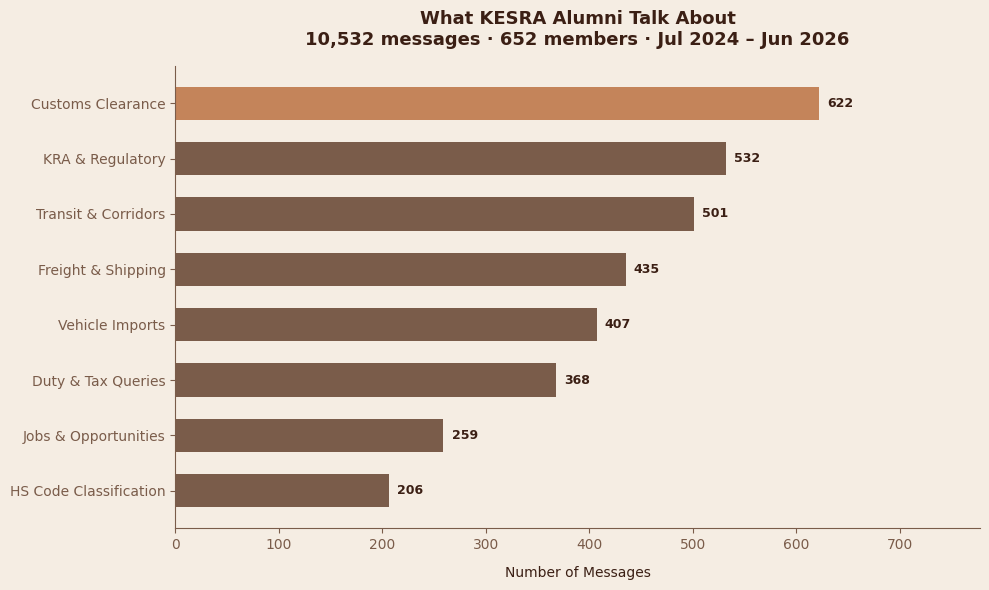

Saved.


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

topic_plot = topic_df[topic_df['Topic'] != 'General / Other']
colors = [TERRACOTTA if i == 0 else MID for i in range(len(topic_plot))]
bars = ax.barh(topic_plot['Topic'], topic_plot['Messages'], color=colors, height=0.6)

for bar, val in zip(bars, topic_plot['Messages']):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color=BROWN, fontweight='bold')

ax.set_xlabel('Number of Messages', labelpad=10)
ax.set_title('What KESRA Alumni Talk About\n10,532 messages · 652 members · Jul 2024 – Jun 2026',
             fontsize=13, fontweight='bold', color=BROWN, pad=15)
ax.invert_yaxis()
ax.set_xlim(0, topic_plot['Messages'].max() * 1.25)
plt.tight_layout()
plt.savefig('01_topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

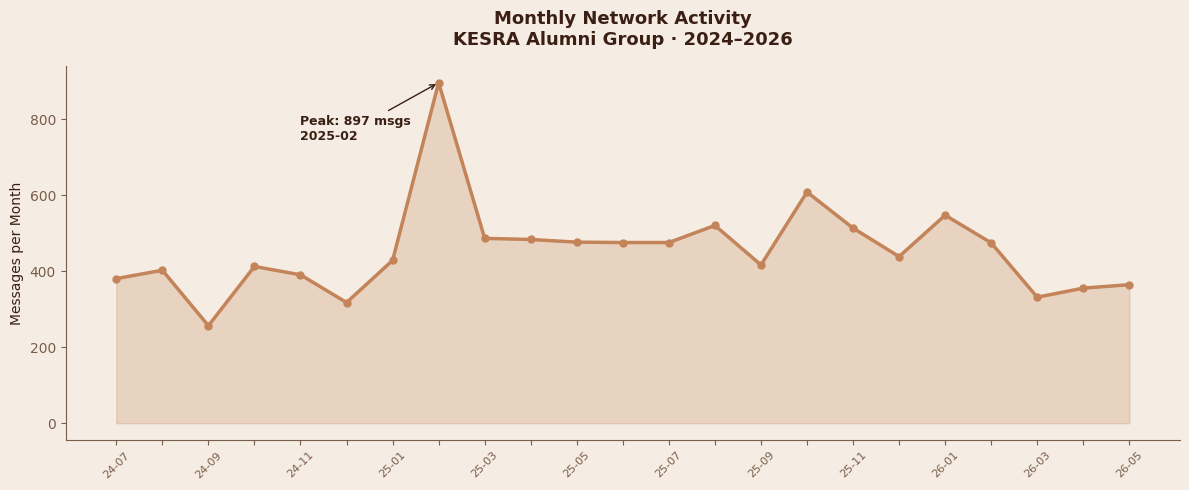

Saved.


In [6]:
monthly = df.groupby('month').size().reset_index(name='messages')
monthly = monthly[monthly['month'] < '2026-06']

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(range(len(monthly)), monthly['messages'],
                alpha=0.25, color=TERRACOTTA)
ax.plot(range(len(monthly)), monthly['messages'],
        color=TERRACOTTA, linewidth=2.5, marker='o', markersize=5)

peak_idx = monthly['messages'].idxmax()
ax.annotate(
    f"Peak: {monthly.loc[peak_idx, 'messages']:,} msgs\n{monthly.loc[peak_idx, 'month']}",
    xy=(peak_idx, monthly.loc[peak_idx, 'messages']),
    xytext=(peak_idx - 3, monthly.loc[peak_idx, 'messages'] - 150),
    arrowprops=dict(arrowstyle='->', color=BROWN),
    color=BROWN, fontsize=9, fontweight='bold'
)

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(
    [m[2:] if i % 2 == 0 else '' for i, m in enumerate(monthly['month'])],
    rotation=45, fontsize=8
)
ax.set_ylabel('Messages per Month')
ax.set_title('Monthly Network Activity\nKESRA Alumni Group · 2024–2026',
             fontsize=13, fontweight='bold', color=BROWN, pad=15)
plt.tight_layout()
plt.savefig('02_monthly_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

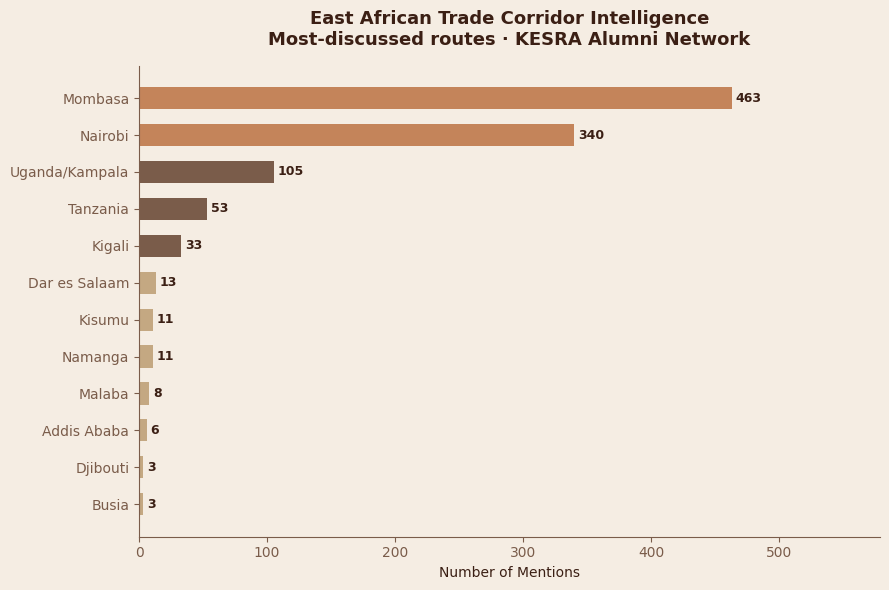

Saved.


In [7]:
CORRIDORS = {
    'Mombasa':        r'mombasa',
    'Nairobi':        r'nairobi',
    'Uganda/Kampala': r'uganda|kampala',
    'Tanzania':       r'tanzania',
    'Kigali':         r'kigali',
    'Dar es Salaam':  r'dar es salaam',
    'Addis Ababa':    r'addis',
    'Kisumu':         r'kisumu',
    'Namanga':        r'namanga',
    'Malaba':         r'malaba',
    'Djibouti':       r'djibouti',
    'Busia':          r'busia',
}

corridor_counts = {
    name: df_text['text'].str.lower().str.count(pattern).sum()
    for name, pattern in CORRIDORS.items()
}

corridor_df = pd.DataFrame(
    sorted(corridor_counts.items(), key=lambda x: -x[1]),
    columns=['Corridor', 'Mentions']
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = [TERRACOTTA if i < 2 else MID if i < 5 else LIGHT
          for i in range(len(corridor_df))]
bars = ax.barh(corridor_df['Corridor'], corridor_df['Mentions'],
               color=colors, height=0.6)

for bar, val in zip(bars, corridor_df['Mentions']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=9,
            color=BROWN, fontweight='bold')

ax.set_xlabel('Number of Mentions')
ax.set_title('East African Trade Corridor Intelligence\nMost-discussed routes · KESRA Alumni Network',
             fontsize=13, fontweight='bold', color=BROWN, pad=15)
ax.invert_yaxis()
ax.set_xlim(0, corridor_df['Mentions'].max() * 1.25)
plt.tight_layout()
plt.savefig('03_corridor_mentions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

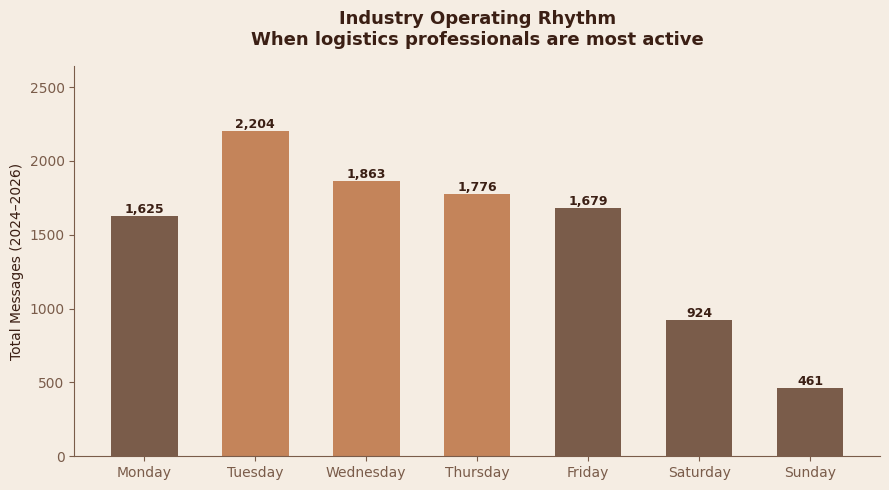

Saved.


In [8]:
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week').size().reindex(days_order)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [TERRACOTTA if d in ['Tuesday','Wednesday','Thursday'] else MID
          for d in days_order]
bars = ax.bar(days_order, dow.values, color=colors, width=0.6)

for bar, val in zip(bars, dow.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=9,
            color=BROWN, fontweight='bold')

ax.set_ylabel('Total Messages (2024–2026)')
ax.set_title('Industry Operating Rhythm\nWhen logistics professionals are most active',
             fontsize=13, fontweight='bold', color=BROWN, pad=15)
ax.set_ylim(0, dow.max() * 1.2)
plt.tight_layout()
plt.savefig('04_weekly_rhythm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

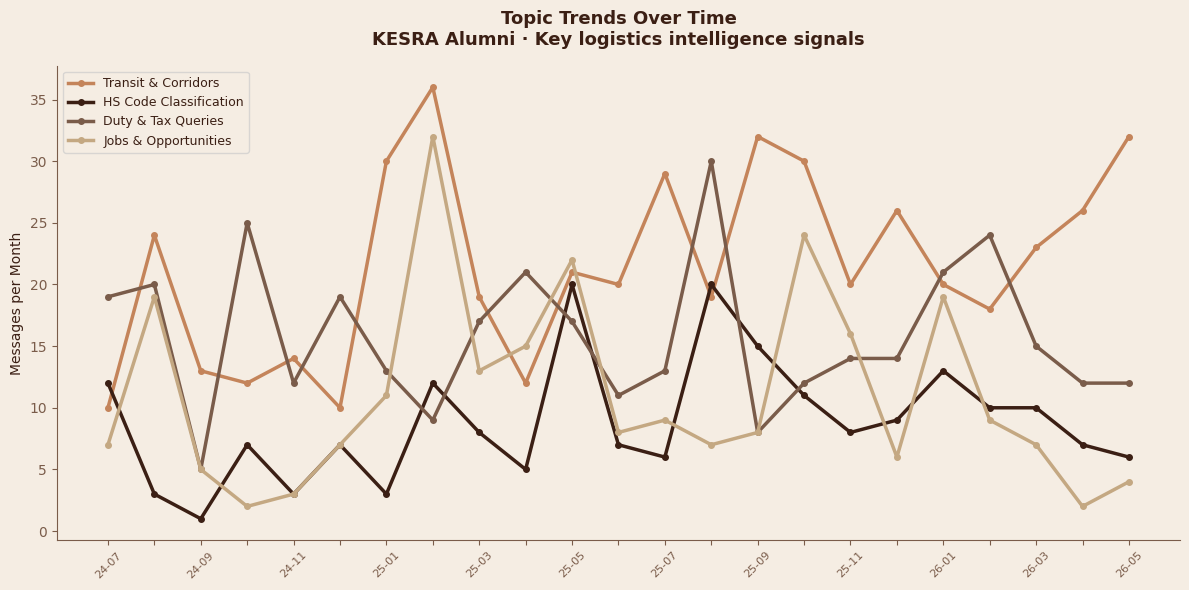

Saved.


In [9]:
key_topics = ['Transit & Corridors', 'HS Code Classification',
              'Duty & Tax Queries', 'Jobs & Opportunities']

topic_monthly = defaultdict(lambda: defaultdict(int))
for _, row in df_text.iterrows():
    for topic in row['topics']:
        if topic in key_topics:
            topic_monthly[topic][row['month']] += 1

months = sorted([m for m in df_text['month'].unique() if m < '2026-06'])

fig, ax = plt.subplots(figsize=(12, 6))
palette_lines = [TERRACOTTA, BROWN, MID, LIGHT]

for topic, color in zip(key_topics, palette_lines):
    values = [topic_monthly[topic].get(m, 0) for m in months]
    ax.plot(range(len(months)), values, label=topic,
            color=color, linewidth=2.5, marker='o', markersize=4)

ax.set_xticks(range(len(months)))
ax.set_xticklabels(
    [m[2:] if i % 2 == 0 else '' for i, m in enumerate(months)],
    rotation=45, fontsize=8
)
ax.set_ylabel('Messages per Month')
ax.set_title('Topic Trends Over Time\nKESRA Alumni · Key logistics intelligence signals',
             fontsize=13, fontweight='bold', color=BROWN, pad=15)
ax.legend(loc='upper left', framealpha=0.7, fontsize=9)
plt.tight_layout()
plt.savefig('05_topic_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [10]:
findings = {
    'Metric': [
        'Total messages analysed',
        'Active members',
        'Date range',
        'Top discussion topic',
        'Dominant trade corridor',
        'Network activity peak',
        'Busiest day of week',
        'HS Code pain point rank',
    ],
    'Finding': [
        '10,532 messages',
        '652 unique members',
        'July 2024 – June 2026',
        'Customs Clearance (622 messages)',
        'Mombasa (463 mentions) → Nairobi (340)',
        'February 2025 — 897 messages in one month',
        'Tuesday (2,204 messages)',
        '#8 of 8 topics — consistent but underserved',
    ],
    'Business Implication': [
        'Statistically significant sample for trend analysis',
        'Large enough network to represent industry sentiment',
        'Two full years — seasonal patterns are detectable',
        'Clearance complexity is the #1 operational pain point',
        'Mombasa–Nairobi is the critical node in EA trade',
        'Activity spikes correlate with regulatory events, not seasons',
        'Tuesday is optimal for automated reports and alerts',
        'Automation opportunity — demand exists, supply is manual',
    ]
}

findings_df = pd.DataFrame(findings)
print(findings_df.to_string(index=False))
print("\nAnalysis complete. 5 charts saved.")

                 Metric                                     Finding                                          Business Implication
Total messages analysed                             10,532 messages           Statistically significant sample for trend analysis
         Active members                          652 unique members          Large enough network to represent industry sentiment
             Date range                       July 2024 – June 2026             Two full years — seasonal patterns are detectable
   Top discussion topic            Customs Clearance (622 messages)         Clearance complexity is the #1 operational pain point
Dominant trade corridor      Mombasa (463 mentions) → Nairobi (340)              Mombasa–Nairobi is the critical node in EA trade
  Network activity peak   February 2025 — 897 messages in one month Activity spikes correlate with regulatory events, not seasons
    Busiest day of week                    Tuesday (2,204 messages)           Tuesday is o

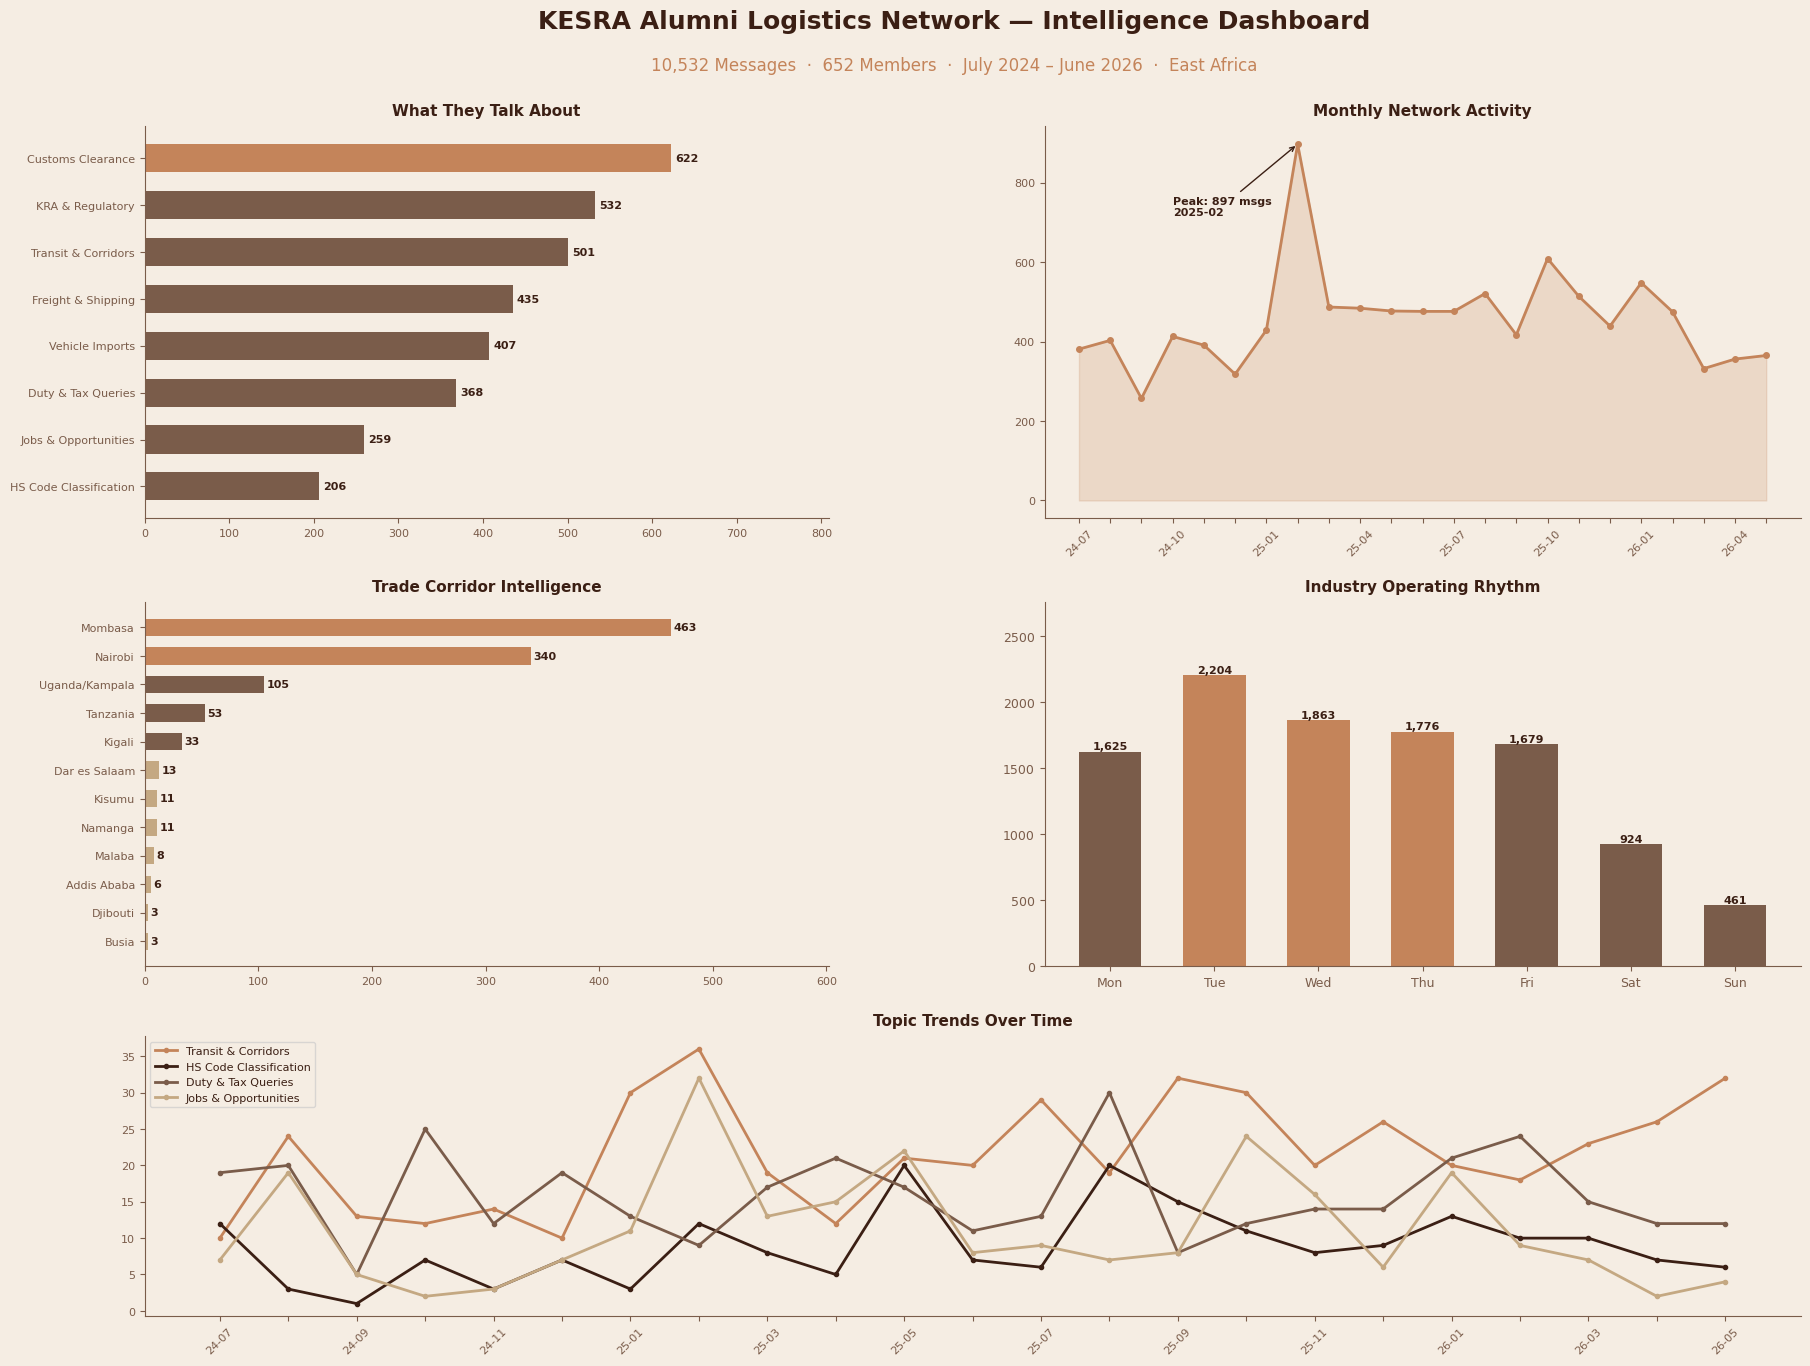

Dashboard .


In [12]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(CREAM)

# Title header
fig.text(0.5, 0.97, 'KESRA Alumni Logistics Network — Intelligence Dashboard',
         ha='center', fontsize=18, fontweight='bold', color=BROWN)
fig.text(0.5, 0.94, '10,532 Messages  ·  652 Members  ·  July 2024 – June 2026  ·  East Africa',
         ha='center', fontsize=12, color=TERRACOTTA)

# ── CHART 1: Topic Distribution (top left) ──────────────────────────────────
ax1 = fig.add_axes([0.05, 0.62, 0.38, 0.28])
ax1.set_facecolor(CREAM)
topic_plot = topic_df[topic_df['Topic'] != 'General / Other']
colors1 = [TERRACOTTA if i == 0 else MID for i in range(len(topic_plot))]
bars1 = ax1.barh(topic_plot['Topic'], topic_plot['Messages'], color=colors1, height=0.6)
for bar, val in zip(bars1, topic_plot['Messages']):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8, color=BROWN, fontweight='bold')
ax1.invert_yaxis()
ax1.set_xlim(0, topic_plot['Messages'].max() * 1.3)
ax1.set_title('What They Talk About', fontsize=11, fontweight='bold', color=BROWN, pad=8)
ax1.tick_params(labelsize=8)
for spine in ['top','right']: ax1.spines[spine].set_visible(False)
ax1.spines['left'].set_color(MID)
ax1.spines['bottom'].set_color(MID)

# ── CHART 2: Monthly Activity (top right) ───────────────────────────────────
ax2 = fig.add_axes([0.55, 0.62, 0.42, 0.28])
ax2.set_facecolor(CREAM)
monthly2 = df.groupby('month').size().reset_index(name='messages')
monthly2 = monthly2[monthly2['month'] < '2026-06']
ax2.fill_between(range(len(monthly2)), monthly2['messages'], alpha=0.2, color=TERRACOTTA)
ax2.plot(range(len(monthly2)), monthly2['messages'],
         color=TERRACOTTA, linewidth=2, marker='o', markersize=4)
peak_idx2 = monthly2['messages'].idxmax()
ax2.annotate(f"Peak: {monthly2.loc[peak_idx2, 'messages']} msgs\n{monthly2.loc[peak_idx2, 'month']}",
             xy=(peak_idx2, monthly2.loc[peak_idx2, 'messages']),
             xytext=(peak_idx2 - 4, monthly2.loc[peak_idx2, 'messages'] - 180),
             arrowprops=dict(arrowstyle='->', color=BROWN),
             color=BROWN, fontsize=8, fontweight='bold')
ax2.set_xticks(range(len(monthly2)))
ax2.set_xticklabels([m[2:] if i % 3 == 0 else '' for i, m in enumerate(monthly2['month'])],
                     rotation=45, fontsize=7)
ax2.set_title('Monthly Network Activity', fontsize=11, fontweight='bold', color=BROWN, pad=8)
ax2.tick_params(labelsize=8)
for spine in ['top','right']: ax2.spines[spine].set_visible(False)
ax2.spines['left'].set_color(MID)
ax2.spines['bottom'].set_color(MID)

# ── CHART 3: Corridors (middle left) ────────────────────────────────────────
ax3 = fig.add_axes([0.05, 0.30, 0.38, 0.26])
ax3.set_facecolor(CREAM)
colors3 = [TERRACOTTA if i < 2 else MID if i < 5 else LIGHT for i in range(len(corridor_df))]
bars3 = ax3.barh(corridor_df['Corridor'], corridor_df['Mentions'], color=colors3, height=0.6)
for bar, val in zip(bars3, corridor_df['Mentions']):
    ax3.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             str(int(val)), va='center', fontsize=8, color=BROWN, fontweight='bold')
ax3.invert_yaxis()
ax3.set_xlim(0, corridor_df['Mentions'].max() * 1.3)
ax3.set_title('Trade Corridor Intelligence', fontsize=11, fontweight='bold', color=BROWN, pad=8)
ax3.tick_params(labelsize=8)
for spine in ['top','right']: ax3.spines[spine].set_visible(False)
ax3.spines['left'].set_color(MID)
ax3.spines['bottom'].set_color(MID)

# ── CHART 4: Day of Week (middle right) ─────────────────────────────────────
ax4 = fig.add_axes([0.55, 0.30, 0.42, 0.26])
ax4.set_facecolor(CREAM)
days_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
days_full  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow2 = df.groupby('day_of_week').size().reindex(days_full)
colors4 = [TERRACOTTA if d in ['Tuesday','Wednesday','Thursday'] else MID for d in days_full]
bars4 = ax4.bar(days_order, dow2.values, color=colors4, width=0.6)
for bar, val in zip(bars4, dow2.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f'{val:,}', ha='center', fontsize=8, color=BROWN, fontweight='bold')
ax4.set_ylim(0, dow2.max() * 1.25)
ax4.set_title('Industry Operating Rhythm', fontsize=11, fontweight='bold', color=BROWN, pad=8)
ax4.tick_params(labelsize=9)
for spine in ['top','right']: ax4.spines[spine].set_visible(False)
ax4.spines['left'].set_color(MID)
ax4.spines['bottom'].set_color(MID)

# ── CHART 5: Topic Trends (bottom full width) ────────────────────────────────
ax5 = fig.add_axes([0.05, 0.05, 0.92, 0.20])
ax5.set_facecolor(CREAM)
palette_lines = [TERRACOTTA, BROWN, MID, LIGHT]
for topic, color in zip(key_topics, palette_lines):
    values = [topic_monthly[topic].get(m, 0) for m in months]
    ax5.plot(range(len(months)), values, label=topic,
             color=color, linewidth=2, marker='o', markersize=3)
ax5.set_xticks(range(len(months)))
ax5.set_xticklabels([m[2:] if i % 2 == 0 else '' for i, m in enumerate(months)],
                     rotation=45, fontsize=7)
ax5.set_title('Topic Trends Over Time', fontsize=11, fontweight='bold', color=BROWN, pad=8)
ax5.legend(loc='upper left', framealpha=0.7, fontsize=8)
ax5.tick_params(labelsize=8)
for spine in ['top','right']: ax5.spines[spine].set_visible(False)
ax5.spines['left'].set_color(MID)
ax5.spines['bottom'].set_color(MID)

plt.savefig('kesra_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard .")

In [19]:
hs_msgs = df_text[
    df_text['text'].str.lower().str.contains(
        r'hs code|tariff|chapter \d+|heading|subheading|classification|hs \d+|chapter 6|chapter 8|chapter 9',
        regex=True
    )
].copy()

print(f"Total HS-related messages: {len(hs_msgs)}")
print(f"\n--- Sample of 20 messages ---\n")
for i, row in hs_msgs.head(20).iterrows():
    print(f"{row['date'].strftime('%b %Y')} | {row['text'][:200]}")
    print("---")

Total HS-related messages: 181

--- Sample of 20 messages ---

Jul 2024 | Hi all, 
Kindly advice on the correct Tariff and Import taxes applicable when importing *Premium Grade 1/A or first quality clothes (factory rejects)*
---
Jul 2024 | It falls under Chapter 61 or 62 of the HS code. But specific code will depend on the exact type and material of the clothing items. Mayb ulete descriptions ya clothes
---
Jul 2024 | HS code
---
Jul 2024 | Where is HS code generation 😭😯😭😭😭????
---
Jul 2024 | What is the HS code 😲😲😲????
---
Jul 2024 | @⁨~KN⁩ chapter 7,HS code 07133100🤦🏿‍♀️
---
Jul 2024 | We agreed this group is for HS code and clearing related issues.
---
Jul 2024 | This is related to our field thanks to @⁨~Peter⁩ I have diverted vehicles heading to Kampala and Nakuru to Southern bypass
---
Jul 2024 | This kind of  info is important. It for sure give a caution to anyone in that or  heading in that direction.
---
Jul 2024 | Correct hs code ya Guidewire plz
---
Jul 2024 | Kindly help me 

In [20]:
# Extract actual HS codes mentioned (6-8 digit numbers)
hs_code_pattern = r'\b(\d{6,8})\b'
hs_msgs['extracted_codes'] = hs_msgs['text'].apply(
    lambda x: re.findall(hs_code_pattern, x)
)

# Extract chapter references
chapter_pattern = r'chapter\s+(\d{1,2})'
hs_msgs['chapters'] = hs_msgs['text'].str.lower().apply(
    lambda x: re.findall(chapter_pattern, x)
)

# Classify commodity type from message text
COMMODITIES = {
    'Textiles & Clothing':  ['cloth', 'textile', 'fabric', 'garment', 'wear',
                              'chapter 61', 'chapter 62', 'cotton', 'apparel'],
    'Vehicles & Parts':     ['vehicle', 'car', 'motor', 'spare', 'parts',
                              'chapter 87', 'tyre', 'engine'],
    'Food & Agriculture':   ['food', 'grain', 'rice', 'maize', 'wheat', 'sugar',
                              'chapter 10', 'chapter 17', 'agriculture', 'farm'],
    'Machinery & Equipment':['machine', 'equipment', 'pump', 'generator',
                              'chapter 84', 'chapter 85', 'electric', 'motor'],
    'Chemicals & Plastics': ['chemical', 'plastic', 'rubber', 'paint',
                              'chapter 39', 'chapter 40', 'solvent'],
    'Medical & Health':     ['medical', 'medicine', 'pharmaceutical', 'drug',
                              'glove', 'mask', 'health', 'chapter 30'],
    'Construction':         ['steel', 'iron', 'cement', 'pipe', 'wire',
                              'chapter 72', 'chapter 73', 'building'],
    'Electronics':          ['phone', 'computer', 'electronic', 'cable',
                              'chapter 85', 'laptop', 'tablet'],
}

def classify_commodity(text):
    tl = text.lower()
    for commodity, kws in COMMODITIES.items():
        if any(kw in tl for kw in kws):
            return commodity
    return 'Other / Unclassified'

hs_msgs['commodity'] = hs_msgs['text'].apply(classify_commodity)

# All codes found
all_codes = [code for codes in hs_msgs['extracted_codes'] for code in codes]
all_chapters = [ch for chs in hs_msgs['chapters'] for ch in chs]

print(f"HS codes extracted: {len(all_codes)}")
print(f"Chapter references: {len(all_chapters)}")
print(f"\nTop HS codes mentioned:")
for code, count in Counter(all_codes).most_common(10):
    print(f"  {code}: {count} times")
print(f"\nTop chapters mentioned:")
for ch, count in Counter(all_chapters).most_common(10):
    print(f"  Chapter {ch}: {count} times")
print(f"\nCommodity breakdown:")
print(hs_msgs['commodity'].value_counts().to_string())

HS codes extracted: 14
Chapter references: 7

Top HS codes mentioned:
  850940: 2 times
  07133100: 1 times
  27101951: 1 times
  391990: 1 times
  39233000: 1 times
  371618: 1 times
  23099010: 1 times
  23099090: 1 times
  850490: 1 times
  850760: 1 times

Top chapters mentioned:
  Chapter 85: 2 times
  Chapter 61: 1 times
  Chapter 7: 1 times
  Chapter 19: 1 times
  Chapter 57: 1 times
  Chapter 48: 1 times

Commodity breakdown:
commodity
Other / Unclassified     128
Vehicles & Parts          17
Machinery & Equipment      8
Textiles & Clothing        7
Food & Agriculture         6
Electronics                6
Construction               5
Chemicals & Plastics       3
Medical & Health           1


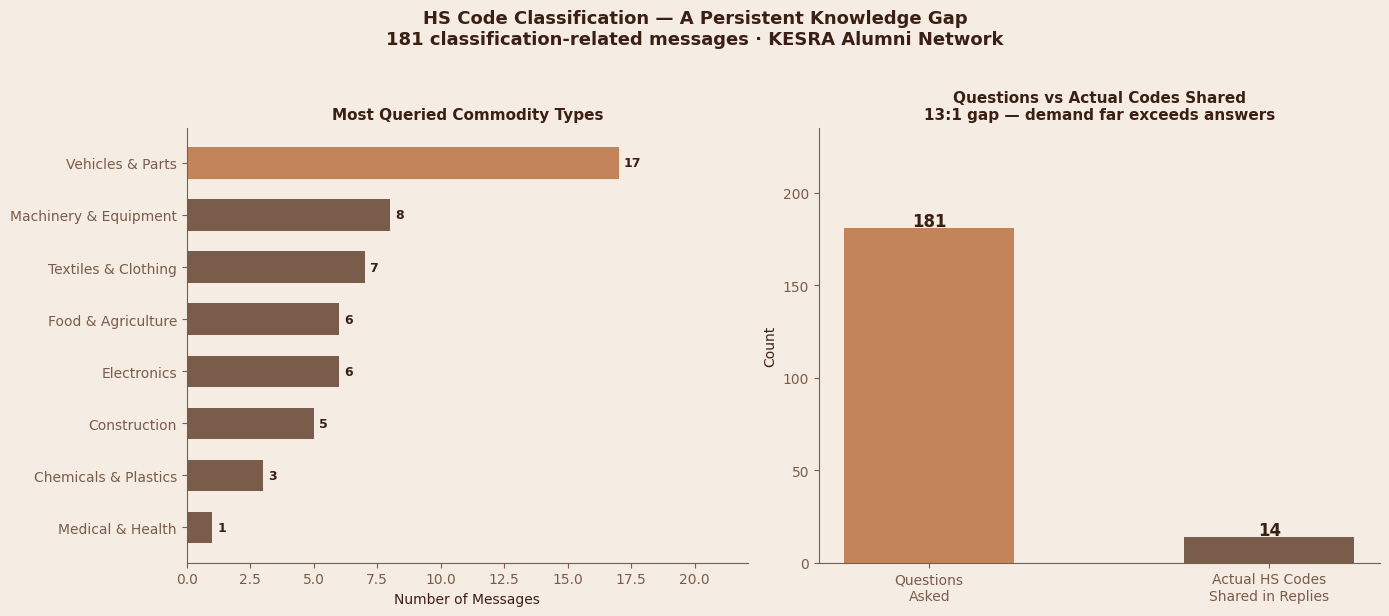

Saved.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(CREAM)
fig.suptitle('HS Code Classification — A Persistent Knowledge Gap\n181 classification-related messages · KESRA Alumni Network',
             fontsize=13, fontweight='bold', color=BROWN, y=1.02)

# Chart A: Commodity breakdown (exclude Other)
ax1 = axes[0]
ax1.set_facecolor(CREAM)
commodity_plot = hs_msgs['commodity'].value_counts()
commodity_plot = commodity_plot[commodity_plot.index != 'Other / Unclassified']
colors_c = [TERRACOTTA if i == 0 else MID for i in range(len(commodity_plot))]
bars1 = ax1.barh(commodity_plot.index, commodity_plot.values, color=colors_c, height=0.6)
for bar, val in zip(bars1, commodity_plot.values):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9, color=BROWN, fontweight='bold')
ax1.invert_yaxis()
ax1.set_xlim(0, commodity_plot.max() * 1.3)
ax1.set_title('Most Queried Commodity Types', fontsize=11, fontweight='bold', color=BROWN)
ax1.set_xlabel('Number of Messages')
for spine in ['top','right']: ax1.spines[spine].set_visible(False)

# Chart B: Questions vs Answers ratio
ax2 = axes[1]
ax2.set_facecolor(CREAM)
total_hs = len(hs_msgs)
codes_shared = len(all_codes)
unanswered = total_hs - codes_shared

categories = ['Questions\nAsked', 'Actual HS Codes\nShared in Replies']
values = [total_hs, codes_shared]
colors_r = [TERRACOTTA, MID]
bars2 = ax2.bar(categories, values, color=colors_r, width=0.5)
for bar, val in zip(bars2, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=12, color=BROWN, fontweight='bold')

ax2.set_ylim(0, max(values) * 1.3)
ax2.set_title('Questions vs Actual Codes Shared\n13:1 gap — demand far exceeds answers',
              fontsize=11, fontweight='bold', color=BROWN)
ax2.set_ylabel('Count')
for spine in ['top','right']: ax2.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('06_hs_code_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")